# Week 3 - Fit of Models

In [17]:
import pandas as pd 
import jax.numpy as jnp
import jax

from src.api.v4 import HMM, GaussEmission, StaticTransition, AutoregressiveGaussEmission, DynamicTransition 
import matplotlib.pyplot as plt

In [18]:
jax.config.update("jax_enable_x64", True)

In [63]:
DATA_PATH = "data/dtu/" 
ROOM_FILE = "Room 007"

In [64]:
covariates = pd.read_csv(DATA_PATH + "covariates_halfhour.csv", index_col=0)
covariates

,mean_temp,mean_relative_hum,mean_wind_speed,mean_wind_dir,mean_pressure,mean_cloud_cover,mean_radiation,is_holiday,is_weekend,tod_cos,tod_sin
datetime,,,,,,,,,,,
2023-11-01 14:00:00,6.10,73.90,3.80,137.0,1004.10,99.0,98.00,0,0,-0.866025,-5.000000e-01
2023-11-01 14:30:00,6.10,75.95,4.00,134.5,1003.65,96.5,63.80,0,0,-0.793353,-6.087614e-01
2023-11-01 15:00:00,6.10,78.00,4.20,132.0,1003.20,94.0,29.60,0,0,-0.707107,-7.071068e-01
2023-11-01 15:30:00,6.20,80.10,4.75,130.5,1002.75,97.0,15.60,0,0,-0.608761,-7.933533e-01
2023-11-01 16:00:00,6.30,82.20,5.30,129.0,1002.30,100.0,1.60,0,0,-0.500000,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-09 11:00:00,0.10,77.90,4.90,99.0,998.00,97.0,56.50,0,0,-0.965926,2.588190e-01
2024-02-09 11:30:00,0.15,78.50,5.10,100.5,997.60,98.5,60.65,0,0,-0.991445,1.305262e-01
2024-02-09 12:00:00,0.20,79.10,5.30,102.0,997.20,100.0,64.80,0,0,-1.000000,1.224647e-16


In [65]:
df_room = pd.read_csv(DATA_PATH + "timeseries_halfhour/" + ROOM_FILE + ".csv", index_col=0)
df_room

,co2,temperature,humidity,closed_frac
datetime,,,,
2023-11-01 14:00:00,1722.500000,23.150000,50.975,1.0
2023-11-01 14:30:00,1572.666667,23.200000,49.610,1.0
2023-11-01 15:00:00,1580.000000,23.233333,49.090,1.0
2023-11-01 15:30:00,1538.333333,23.300000,48.700,1.0
2023-11-01 16:00:00,1459.000000,23.200000,48.700,1.0
...,...,...,...,...
2024-02-09 11:00:00,1387.000000,22.400000,41.410,1.0
2024-02-09 11:30:00,1337.000000,22.100000,41.020,1.0
2024-02-09 12:00:00,1225.333333,21.866667,41.020,1.0


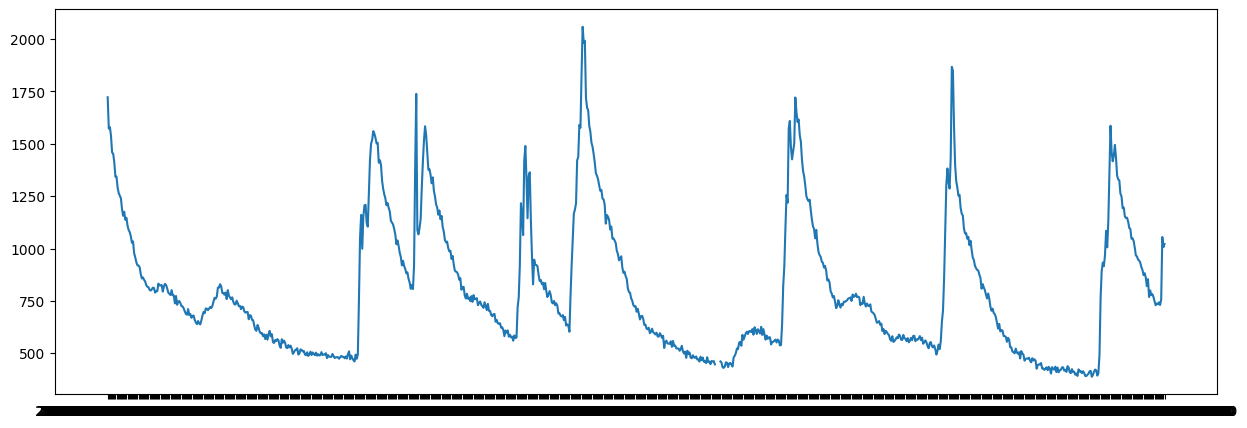

In [66]:
plt.figure(figsize=(15, 5))
DAYS = 20
plt.plot(df_room.index[:48*DAYS], df_room["co2"][:48*DAYS], label="CO2")


In [35]:
pd.to_datetime(df_room.index).hour

Index([14, 14, 15, 15, 16, 16, 17, 17, 18, 18,
       ...
        8,  9,  9, 10, 10, 11, 11, 12, 12, 13],
      dtype='int32', name='datetime', length=4799)

In [39]:
df_night = df_room[pd.to_datetime(df_room.index).hour.isin([3])] 

<Axes: >

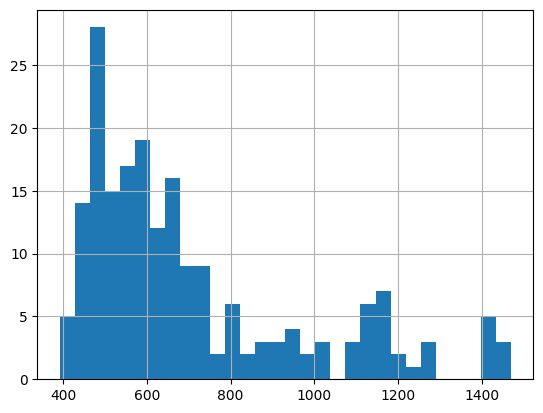

In [40]:
df_night["co2"].hist(bins=30)

In [44]:
df_night['co2'].isna().sum()

np.int64(1)

In [45]:
import numpy as np

counts, bin_edges = np.histogram(df_night['co2'].dropna(), bins=30)

max_idx = np.argmax(counts)
most_frequent_interval = (bin_edges[max_idx], bin_edges[max_idx + 1])

print(most_frequent_interval)

(np.float64(463.8222222222222), np.float64(499.73333333333335))
